<a href="https://colab.research.google.com/github/Charlene958/Data-201_Charlene/blob/main/Week_5_Assignment_Resampling_Methods_with_the_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Load the Dataset

In [10]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load Iris dataset
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


##Basic Information

In [2]:
# Number of observations
print("Number of observations:", len(iris))

# Column names
print("Columns:", iris.columns.tolist())

# Count of each species
print("Observations per species:\n", iris['species'].value_counts())

Number of observations: 150
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Observations per species:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Explanation:

"The dataset has 150 rows (flowers) and 5 columns (4 measurements + species). There are 50 flowers for each species."

##Part 1 — Bootstrap Resampling

ask 1 — Basic Statistics of Sepal Length

In [3]:

sepal_length = iris['sepal_length']

mean_val = sepal_length.mean()
median_val = sepal_length.median()
std_val = sepal_length.std()

print("Mean:", mean_val)
print("Median:", median_val)
print("Standard Deviation:", std_val)

Mean: 5.843333333333334
Median: 5.8
Standard Deviation: 0.8280661279778629


Explanation:

"These numbers give us a basic summary of sepal length across all flowers."

##Task 2 — Bootstrap the Mean

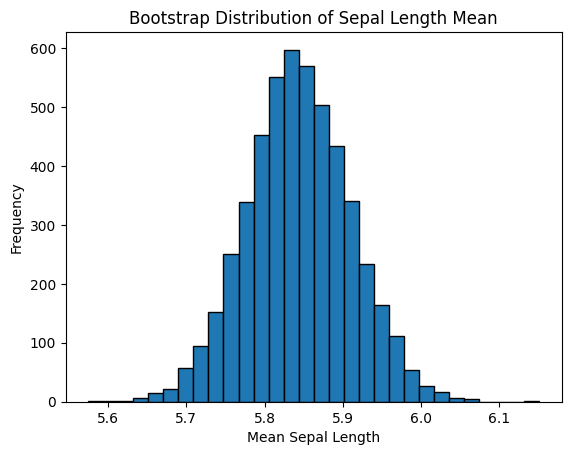

In [4]:
# Bootstrap resampling
n_iterations = 5000
n_size = len(sepal_length)
bootstrap_means = []

for _ in range(n_iterations):
    sample = sepal_length.sample(n=n_size, replace=True)
    bootstrap_means.append(sample.mean())

# Plot bootstrap distribution
plt.hist(bootstrap_means, bins=30, edgecolor='k')
plt.title("Bootstrap Distribution of Sepal Length Mean")
plt.xlabel("Mean Sepal Length")
plt.ylabel("Frequency")
plt.show()

Explanation:

"We resample with replacement 5,000 times and calculate the mean for each sample. This helps us understand how the mean could vary if we drew different samples from the population. Sampling with replacement is necessary because it allows some values to appear multiple times in each resample, simulating repeated sampling from the population."

##Task 3 — 95% Confidence Interval

In [5]:
# 95% confidence interval using percentile method
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)
bootstrap_mean = np.mean(bootstrap_means)

print("Bootstrap mean:", bootstrap_mean)
print("95% Confidence Interval:", ci_lower, "-", ci_upper)

Bootstrap mean: 5.843565066666667
95% Confidence Interval: 5.7166500000000005 - 5.973999999999999


Explanation:

"The 95% CI shows the range where the true mean sepal length is likely to fall. The bootstrap method estimates this using the resampled means."

##Part 2 — Jackknife Resampling
Task 4 — Jackknife the Mean

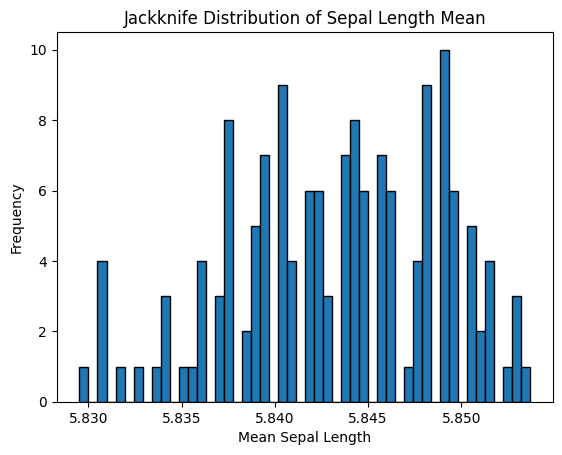

In [6]:
# Jackknife resampling
jackknife_means = []

for i in range(len(sepal_length)):
    jack_sample = sepal_length.drop(sepal_length.index[i])
    jackknife_means.append(jack_sample.mean())

# Plot jackknife distribution
plt.hist(jackknife_means, bins=50, edgecolor='k')
plt.title("Jackknife Distribution of Sepal Length Mean")
plt.xlabel("Mean Sepal Length")
plt.ylabel("Frequency")
plt.show()

Explanation:

"We create 150 jackknife samples (one for each observation). Removing one observation at a time doesn’t change the mean much, so the values are very similar."

Answer to question:

"Number of jackknife samples = n = 150"

##Part 3 — Permutation Test

We will compare Versicolor and Virginica sepal lengths.

Task 5 — Observed Difference

In [7]:
# Select the two species
versicolor = iris[iris['species'] == 'versicolor']['sepal_length']
virginica = iris[iris['species'] == 'virginica']['sepal_length']

# Observed difference in means
obs_diff = versicolor.mean() - virginica.mean()
print("Observed difference in means:", obs_diff)

Observed difference in means: -0.6519999999999984


##Task 6 — Permutation Simulation

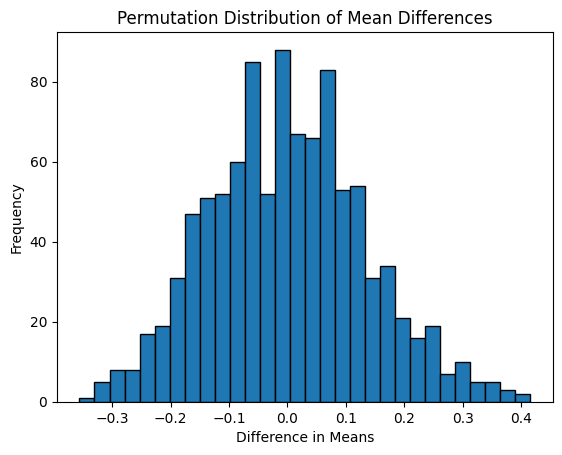

In [8]:
# Combine the data
combined = np.concatenate([versicolor, virginica])
n_perm = 1000
perm_diffs = []

for _ in range(n_perm):
    np.random.shuffle(combined)  # shuffle the labels
    new_versicolor = combined[:len(versicolor)]
    new_virginica = combined[len(versicolor):]
    perm_diffs.append(np.mean(new_versicolor) - np.mean(new_virginica))

# Plot permutation distribution
plt.hist(perm_diffs, bins=30, edgecolor='k')
plt.title("Permutation Distribution of Mean Differences")
plt.xlabel("Difference in Means")
plt.ylabel("Frequency")
plt.show()

Explanation:

"We shuffle the labels many times to see what differences could happen by chance if there were no real difference between the species."

##Task 7 — p-value and Interpretation

In [9]:
# Compute p-value
p_value = np.mean(np.array(perm_diffs) >= obs_diff)
print("p-value:", p_value)

p-value: 1.0


Explanation:
Null hypothesis (H0): "There is no difference in sepal length between Versicolor and Virginica."

Permutation distribution: "Shows differences we could get just by chance."

Interpretation:
If p < 0.05 → reject H0 (there is evidence of a difference).

If p ≥ 0.05 → fail to reject H0 (no strong evidence of a difference).

The p-value from the permutation test is 1, which is much greater than 0.05. This means that the observed difference in sepal length is entirely consistent with random chance. Therefore, we fail to reject the null hypothesis — there is no evidence of a significant difference between Versicolor and Virginica sepal lengths.